In [1]:
import numpy as np
import xarray as xr
import os 
import glob

In [2]:
#Final so far
import dask
from dask.distributed import Client
import os

scheduler_file = os.path.join(os.environ["PSCRATCH"], "scheduler_jupyter.json")

dask.config.config["distributed"]["dashboard"]["link"] = "{JUPYTERHUB_SERVICE_PREFIX}proxy/{host}:{port}/status" 

client = Client(scheduler_file=scheduler_file)
client

<Client: 'tcp://10.249.1.75:8786' processes=12 threads=252, memory=468.93 GiB>

Task exception was never retrieved
future: <Task finished name='Task-264' coro=<Client._gather.<locals>.wait() done, defined at /global/homes/d/dkamnani/.conda/envs/climate_dask/lib/python3.8/site-packages/distributed/client.py:2134> exception=AllExit()>
Traceback (most recent call last):
  File "/global/homes/d/dkamnani/.conda/envs/climate_dask/lib/python3.8/site-packages/distributed/client.py", line 2143, in wait
    raise AllExit()
distributed.client.AllExit


In [3]:
path = "/pscratch/sd/k/kquagra/Side_Jobs/Diya Collab/Categorised_ERA5_WCNA_data/"

# Match all years from 2001 to 2017
file_names = sorted(
    sum(
        [glob.glob(path + f"AR_categorization_{year}*.nc") for year in range(2001, 2018)],
        []
    )
)

In [4]:
#Reading AR Category files
ds = xr.open_mfdataset(file_names)
#print(ds)

In [5]:
AR_event_category = ds['AR_event_category']
print(AR_event_category)

<xarray.DataArray 'AR_event_category' (time: 24712, latitude: 241, longitude: 441)>
dask.array<concatenate, shape=(24712, 241, 441), dtype=int8, chunksize=(124, 241, 441), chunktype=numpy.ndarray>
Coordinates:
  * latitude   (latitude) float64 60.0 59.75 59.5 59.25 ... 0.75 0.5 0.25 0.0
  * longitude  (longitude) float64 -160.0 -159.8 -159.5 ... -50.5 -50.25 -50.0
  * time       (time) datetime64[ns] 2001-01-01 ... 2017-12-31T18:00:00
Attributes:
    units:          1
    long_name:      AR Event Categories
    standard_name:  AR_event_category


In [6]:
#Reading co occurence weather phenomena files
coocurrence_path = "/pscratch/sd/d/dkamnani/Results_data/training_label_*.nc"
ds_co = xr.open_mfdataset(coocurrence_path)
print(ds_co)

<xarray.Dataset>
Dimensions:          (time: 24744, longitude: 1440, latitude: 481)
Coordinates:
  * time             (time) datetime64[ns] 2001-01-01 ... 2017-12-31T18:00:00
  * longitude        (longitude) float64 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8
  * latitude         (latitude) float64 60.0 59.75 59.5 ... -59.5 -59.75 -60.0
Data variables:
    feat_comb_label  (time, latitude, longitude) int8 dask.array<chunksize=(1460, 481, 1440), meta=np.ndarray>


In [7]:
ds_co = ds_co['feat_comb_label']

In [8]:
#Making sure time steps match
matching_times = np.intersect1d(ds_co.time.values, AR_event_category.time.values)
ds_co = ds_co.sel(time=matching_times)
AR_event_category = AR_event_category.sel(time=matching_times)
print(ds_co)
print(AR_event_category)

<xarray.DataArray 'feat_comb_label' (time: 24620, latitude: 481, longitude: 1440)>
dask.array<getitem, shape=(24620, 481, 1440), dtype=int8, chunksize=(1460, 481, 1440), chunktype=numpy.ndarray>
Coordinates:
  * time       (time) datetime64[ns] 2001-01-01 ... 2017-12-31T18:00:00
  * longitude  (longitude) float64 0.0 0.25 0.5 0.75 ... 359.0 359.2 359.5 359.8
  * latitude   (latitude) float64 60.0 59.75 59.5 59.25 ... -59.5 -59.75 -60.0
<xarray.DataArray 'AR_event_category' (time: 24620, latitude: 241, longitude: 441)>
dask.array<getitem, shape=(24620, 241, 441), dtype=int8, chunksize=(124, 241, 441), chunktype=numpy.ndarray>
Coordinates:
  * latitude   (latitude) float64 60.0 59.75 59.5 59.25 ... 0.75 0.5 0.25 0.0
  * longitude  (longitude) float64 -160.0 -159.8 -159.5 ... -50.5 -50.25 -50.0
  * time       (time) datetime64[ns] 2001-01-01 ... 2017-12-31T18:00:00
Attributes:
    units:          1
    long_name:      AR Event Categories
    standard_name:  AR_event_category


/global/homes/d/dkamnani/.conda/envs/climate_dask/lib/python3.8/site-packages/xarray/core/indexing.py:1226: PerformanceWarning: Slicing is producing a large chunk. To accept the large
chunk and silence this warning, set the option
    >>> with dask.config.set(**{'array.slicing.split_large_chunks': False}):
    ...     array[indexer]

To avoid creating the large chunks, set the option
    >>> with dask.config.set(**{'array.slicing.split_large_chunks': True}):
    ...     array[indexer]
  return self.array[key]


In [9]:
#Matching array dimension
ds_co = ds_co.sel(latitude=slice(60, 0))
ds_co = ds_co.assign_coords(
    longitude=(((ds_co.longitude + 180) % 360) - 180)
)

# 2. Sort longitudes (important after reassignment to avoid disordered coords)
ds_co = ds_co.sortby('longitude')

# 3. Select the desired longitude range
ds_co = ds_co.sel(longitude=slice(-160, -50))

In [10]:
print(ds_co)

<xarray.DataArray 'feat_comb_label' (time: 24620, latitude: 241, longitude: 441)>
dask.array<getitem, shape=(24620, 241, 441), dtype=int8, chunksize=(1460, 241, 441), chunktype=numpy.ndarray>
Coordinates:
  * time       (time) datetime64[ns] 2001-01-01 ... 2017-12-31T18:00:00
  * longitude  (longitude) float64 -160.0 -159.8 -159.5 ... -50.5 -50.25 -50.0
  * latitude   (latitude) float64 60.0 59.75 59.5 59.25 ... 0.75 0.5 0.25 0.0


In [11]:
#Teca data - Used for AR event identification
"""
teca_path = "/global/cfs/cdirs/m4374/catalogues/raw_catalogue_files/observations/teca_era5/ERA5_BARD_AR.2005*.nc4"
teca_data = xr.open_mfdataset(teca_path)
teca_data = teca_data["ar_binary_tag"]
print(teca_data)
"""
# Update path to include all years from 2001 to 2017
teca_path = "/global/cfs/cdirs/m4374/catalogues/raw_catalogue_files/observations/teca_era5/ERA5_BARD_AR.20*.nc4"

# Open all files and subset by time
teca_data = xr.open_mfdataset(teca_path, combine='by_coords')
teca_data = teca_data["ar_binary_tag"]

# Select years 2001 to 2017
teca_data = teca_data.sel(time=slice("2001-01-01", "2017-12-31"))

print(teca_data)

<xarray.DataArray 'ar_binary_tag' (time: 149016, latitude: 721, longitude: 1440)>
dask.array<getitem, shape=(149016, 721, 1440), dtype=int8, chunksize=(744, 721, 1440), chunktype=numpy.ndarray>
Coordinates:
  * time       (time) datetime64[ns] 2001-01-01 ... 2017-12-31T23:00:00
  * latitude   (latitude) float64 -90.0 -89.75 -89.5 -89.25 ... 89.5 89.75 90.0
  * longitude  (longitude) float64 0.0 0.25 0.5 0.75 ... 359.0 359.2 359.5 359.8
Attributes:
    description:  binary indicator of atmospheric river
    long_name:    binary indicator of atmospheric river
    note:         derived by thresholding ar_probability >= 0.666667
    scheme:       TECA_BARD
    units:        unitless
    version:      1.0


In [12]:
time = ds_co.time.values
teca_data = teca_data.sel(time  = time)
print(teca_data)

<xarray.DataArray 'ar_binary_tag' (time: 24620, latitude: 721, longitude: 1440)>
dask.array<getitem, shape=(24620, 721, 1440), dtype=int8, chunksize=(124, 721, 1440), chunktype=numpy.ndarray>
Coordinates:
  * time       (time) datetime64[ns] 2001-01-01 ... 2017-12-31T18:00:00
  * latitude   (latitude) float64 -90.0 -89.75 -89.5 -89.25 ... 89.5 89.75 90.0
  * longitude  (longitude) float64 0.0 0.25 0.5 0.75 ... 359.0 359.2 359.5 359.8
Attributes:
    description:  binary indicator of atmospheric river
    long_name:    binary indicator of atmospheric river
    note:         derived by thresholding ar_probability >= 0.666667
    scheme:       TECA_BARD
    units:        unitless
    version:      1.0


In [13]:
teca_data = teca_data.sel(latitude=slice(0, 60))
teca_data = teca_data.sortby('latitude', ascending = False)

teca_data = teca_data.assign_coords(longitude=(((teca_data.longitude + 180) % 360) - 180))
# 2. Sort longitudes (important after reassignment to avoid disordered coords)
teca_data = teca_data.sortby('longitude')

# 3. Select the desired longitude range
teca_data = teca_data.sel(longitude=slice(-160, -50))
print(teca_data)

<xarray.DataArray 'ar_binary_tag' (time: 24620, latitude: 241, longitude: 441)>
dask.array<getitem, shape=(24620, 241, 441), dtype=int8, chunksize=(124, 241, 441), chunktype=numpy.ndarray>
Coordinates:
  * time       (time) datetime64[ns] 2001-01-01 ... 2017-12-31T18:00:00
  * latitude   (latitude) float64 60.0 59.75 59.5 59.25 ... 0.75 0.5 0.25 0.0
  * longitude  (longitude) float64 -160.0 -159.8 -159.5 ... -50.5 -50.25 -50.0
Attributes:
    description:  binary indicator of atmospheric river
    long_name:    binary indicator of atmospheric river
    note:         derived by thresholding ar_probability >= 0.666667
    scheme:       TECA_BARD
    units:        unitless
    version:      1.0


In [14]:
import numpy as np
import xarray as xr

# Mask to only include points where an AR event occurs
co_data_masked = ds_co * teca_data 

#mask = (AR_event_category == 1)
#co_data_masked = co_data_masked.where(mask)


# Apply mask to co-occurrence data
#co_data_masked = ds_co.where(mask)

# Count frequency of each co-occurrence category at each grid point
co_categories = np.arange(1, 16)
co_counts = []

for cat in co_categories:
    cat_count = (co_data_masked == cat).sum(dim='time')
    co_counts.append(cat_count)

# Stack into a single DataArray: (category, lat, lon)
stacked_counts = xr.concat(co_counts, dim='category')
print(stacked_counts)
stacked_counts['category'] = co_categories



<xarray.DataArray (category: 15, latitude: 241, longitude: 441)>
dask.array<concatenate, shape=(15, 241, 441), dtype=int64, chunksize=(1, 241, 441), chunktype=numpy.ndarray>
Coordinates:
  * longitude  (longitude) float64 -160.0 -159.8 -159.5 ... -50.5 -50.25 -50.0
  * latitude   (latitude) float64 60.0 59.75 59.5 59.25 ... 0.75 0.5 0.25 0.0
Dimensions without coordinates: category


In [15]:
# Dominant category (returns actual label: 1–15)
dominant_category = stacked_counts.idxmax(dim='category')

# Total events at each grid cell
total_counts = stacked_counts.sum(dim='category')
dominant_category = dominant_category.where(total_counts > 0)

# Mask dominant category per grid cell
counts_without_dominant = stacked_counts.where(
    stacked_counts['category'] != dominant_category
)

# Second dominant category (again returns true category ID)
second_dominant_category = counts_without_dominant.idxmax(dim='category')

total_counts = counts_without_dominant.sum(dim='category')

# Mask grid cells with no events
second_dominant_category = second_dominant_category.where(total_counts > 0)

# Second dominant counts
second_dominant_counts = counts_without_dominant.max(dim='category') 
second_dominant_counts = second_dominant_counts.where(total_counts > 0)

# Second dominant percentage
second_dominant_percentage = (second_dominant_counts / total_counts) * 100
second_dominant_percentage = second_dominant_percentage.where(total_counts > 0)


[ 1.  5.  6. ... nan nan nan]


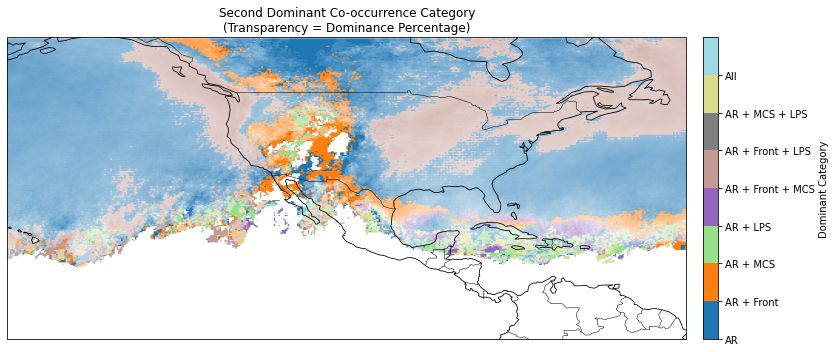

In [30]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.cm as cm
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Define the label index mapping
label_index = {
    1: 'AR',
    2: 'Front',
    3: 'MCS',
    4: 'LPS',
    5: 'AR + Front',
    6: 'AR + MCS',
    7: 'AR + LPS',
    8: 'Front + MCS',
    9: 'Front + LPS',
    10: 'MCS + LPS',
    11: 'AR + Front + MCS',
    12: 'AR + Front + LPS',
    13: 'AR + MCS + LPS',
    14: 'Front + MCS + LPS',
    15: 'All'
}

# --------------------------------------------------
# Alpha (opacity) from dominance percentage
# --------------------------------------------------
alpha = second_dominant_percentage / 100.0
alpha = alpha.clip(min=0.1, max=1.0)
alpha = alpha.fillna(0.0)

# --------------------------------------------------
# Ensure DataArray
# --------------------------------------------------
if not isinstance(second_dominant_category, xr.DataArray):
    second_dominant_category = xr.DataArray(
        second_dominant_category,
        coords=[lat, lon],
        dims=["latitude", "longitude"]
    )

# --------------------------------------------------
# Extract labels actually present
# --------------------------------------------------
unique_vals = np.unique(second_dominant_category.values)
print(unique_vals)
existing_labels = {i: label_index[i] for i in unique_vals if i in label_index}

# --------------------------------------------------
# Discrete colormap + norm
# --------------------------------------------------
cmap = plt.get_cmap("tab20", len(existing_labels))
bounds = list(existing_labels.keys()) + [max(existing_labels.keys()) + 1]
norm = mcolors.BoundaryNorm(bounds, cmap.N)

# --------------------------------------------------
# Build RGBA image (KEY STEP)
# --------------------------------------------------
Z = second_dominant_category.values
A = alpha.values

rgba = cmap(norm(Z))
rgba[..., -1] = A   # inject per-grid-cell alpha

# --------------------------------------------------
# Plot with Cartopy
# --------------------------------------------------
fig = plt.figure(figsize=(12, 5))
ax = plt.axes(projection=ccrs.PlateCarree())

im = ax.imshow(
    rgba,
    origin="upper",
    extent=[
        second_dominant_category.longitude.min(),
        second_dominant_category.longitude.max(),
        second_dominant_category.latitude.min(),
        second_dominant_category.latitude.max(),
    ],
    transform=ccrs.PlateCarree(),
    aspect="auto"
)

ax.coastlines(linewidth=0.8)
ax.add_feature(cfeature.BORDERS, linewidth=0.5)

ax.set_title(
    "Second Dominant Co-occurrence Category\n"
    "(Transparency = Dominance Percentage)"
)

# --------------------------------------------------
# Categorical colorbar (separate ScalarMappable)
# --------------------------------------------------
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

cbar = plt.colorbar(
    sm,
    ax=ax,
    ticks=list(existing_labels.keys()),
    orientation="vertical",
    pad=0.02
)

cbar.set_ticklabels([existing_labels[k] for k in existing_labels])
cbar.set_label("Dominant Category")

plt.tight_layout()
plt.show()


## Category wise dominant category 

In [16]:
# Remap categories: 6 and 7 -> 5
AR_event_category_remap = xr.where(AR_event_category.isin([6, 7]), 5, AR_event_category)

## Final

## Second most dominant 

In [18]:
import numpy as np
import xarray as xr

second_dominant_categories={}
second_dominant_percentages={}

for i in range(1,6):
    # Mask to only include points where an AR event occurs
    co_data_masked = ds_co * teca_data 
    
    mask = (AR_event_category == i)
    co_data_masked = co_data_masked.where(mask)


    # Apply mask to co-occurrence data
    #co_data_masked = ds_co.where(mask)

    # Count frequency of each co-occurrence category at each grid point
    co_categories = np.arange(1, 16)
    co_counts = []

    for cat in co_categories:
        cat_count = (co_data_masked == cat).sum(dim='time')
        co_counts.append(cat_count)

    # Stack into a single DataArray: (category, lat, lon)
    stacked_counts = xr.concat(co_counts, dim='category')
    #print(stacked_counts)
    stacked_counts['category'] = co_categories

    # Dominant category (returns actual label: 1–15)
    dominant_category = stacked_counts.idxmax(dim='category')

    # Total events at each grid cell
    total_counts = stacked_counts.sum(dim='category')
    dominant_category = dominant_category.where(total_counts > 0)

    # Mask dominant category per grid cell
    counts_without_dominant = stacked_counts.where(
        stacked_counts['category'] != dominant_category
    )

    # Second dominant category (again returns true category ID)
    second_dominant_cat = counts_without_dominant.idxmax(dim='category')

    total_counts = counts_without_dominant.sum(dim='category')

    # Mask grid cells with no events
    second_dominant_cat = second_dominant_cat.where(total_counts > 0)

    # Second dominant counts
    second_dominant_cnts = counts_without_dominant.max(dim='category') 
    second_dominant_cnts = second_dominant_cnts.where(total_counts > 0)

    # Second dominant percentage
    second_dominant_percent = (second_dominant_cnts / total_counts) * 100
    second_dominant_percent = second_dominant_percent.where(total_counts > 0)

    second_dominant_categories[i] = second_dominant_cat
    second_dominant_percentages[i] = second_dominant_percent


/tmp/ipykernel_467809/3308078425.py:236: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


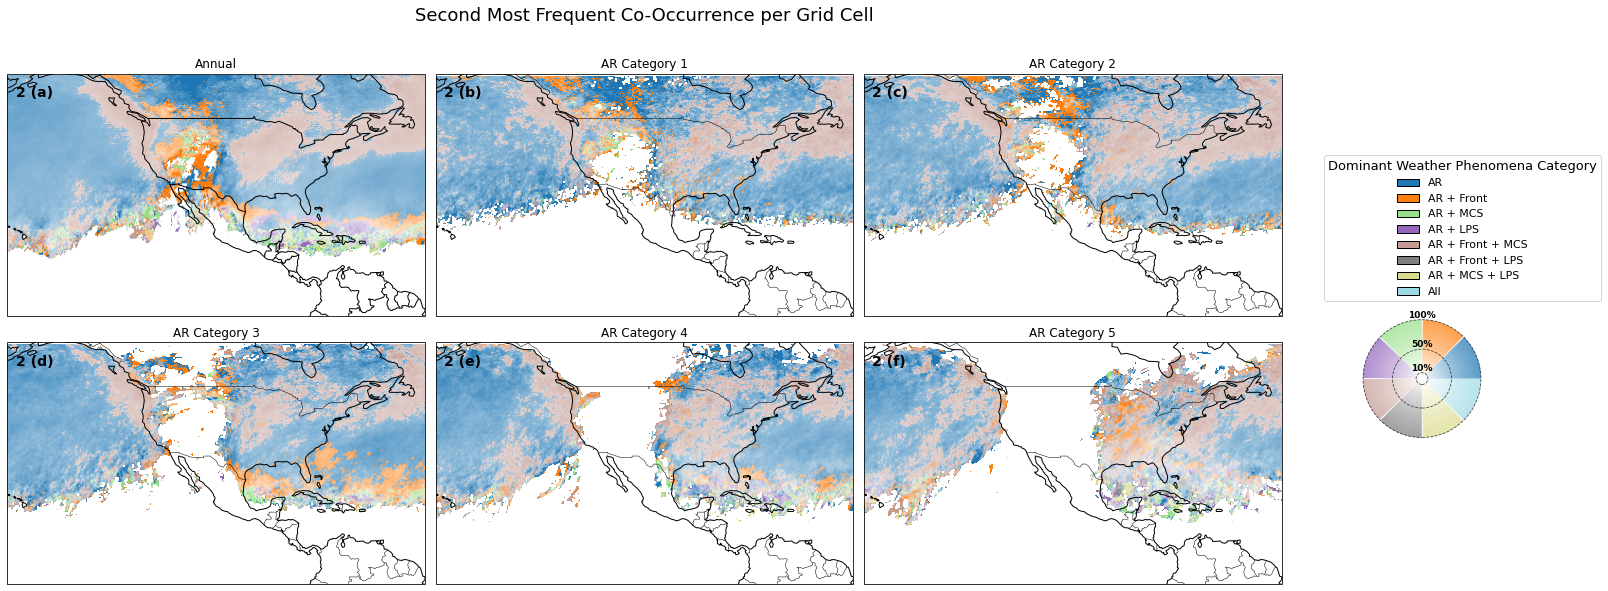

In [20]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np
from matplotlib.colors import ListedColormap, BoundaryNorm
import numpy as np
import xarray as xr
import matplotlib.colors as mcolors
import matplotlib.cm as cm

# List of AR categories to plot
categories_to_plot = [0, 1, 2, 3, 4, 5]

# Label mapping
label_index = {
    1: 'AR', 2: 'Front', 3: 'MCS', 4: 'LPS',
    5: 'AR + Front', 6: 'AR + MCS', 7: 'AR + LPS',
    8: 'Front + MCS', 9: 'Front + LPS', 10: 'MCS + LPS',
    11: 'AR + Front + MCS', 12: 'AR + Front + LPS',
    13: 'AR + MCS + LPS', 14: 'Front + MCS + LPS', 15: 'All'
}

# --------------------------------------------------
# Extract labels actually present
# --------------------------------------------------
unique_vals = np.unique(second_dominant_category.values)
existing_labels = {i: label_index[i] for i in unique_vals if i in label_index}

# --------------------------------------------------
# Discrete colormap + norm
# --------------------------------------------------
cmap15 = plt.get_cmap("tab20", len(existing_labels))
bounds = list(existing_labels.keys()) + [max(existing_labels.keys()) + 1]
norm15 = mcolors.BoundaryNorm(bounds, cmap15.N)

# Color map (15 colors)
#base_cmap = plt.get_cmap('tab20').colors
#cmap15 = ListedColormap(base_cmap[:15])
#boundaries = np.arange(1, 17)  # 1–16
#norm15 = BoundaryNorm(boundaries=boundaries, ncolors=15)

# Figure and axes
fig, axs = plt.subplots(nrows=2, ncols=3, figsize=(18, 8),
                        subplot_kw={'projection': ccrs.PlateCarree()})
axs = axs.ravel()
fig.suptitle(
    "Second Most Frequent Co-Occurrence per Grid Cell",
    fontsize=18,
    y=1.02
)
panel_labels = ['(a)', '(b)', '(c)', '(d)', '(e)', '(f)']
for idx, cat in enumerate(categories_to_plot):
    ax = axs[idx]
    ax.text(
        0.02, 0.95,
        f'2 {panel_labels[idx]}',
        transform=ax.transAxes,
        fontsize=14,
        fontweight='bold',
        va='top',
        ha='left'
    )

    if (idx == 0):
        # --------------------------------------------------
        # Alpha (opacity) from dominance percentage
        # --------------------------------------------------
        gamma=1
        alpha = second_dominant_percentage / 100.0
        alpha = alpha.clip(min=0.1, max=1.0)
        alpha = alpha ** gamma
        alpha = alpha.fillna(0.0)

        Z = second_dominant_category.values
        A = alpha.values

        rgba = cmap15(norm15(Z))
        rgba[..., -1] = A   # inject per-grid-cell alpha
        
        ax.imshow(
            rgba,
            origin="upper",
            extent=[
                second_dominant_category.longitude.min(),
                second_dominant_category.longitude.max(),
                second_dominant_category.latitude.min(),
                second_dominant_category.latitude.max(),
            ],
            transform=ccrs.PlateCarree(),
            aspect="auto"
        )

        ax.coastlines()
        ax.add_feature(cfeature.BORDERS)
        ax.set_title("Annual")
    else :
    # Extract dominant category and alpha for this AR category
        gamma = 1
        dom_cat = second_dominant_categories[cat]          # 1–15
        alpha = second_dominant_percentages[cat] / 100.0   # scale 0–1
        alpha = alpha.clip(min=0.05, max=1.0)       # optional minimum
        alpha = alpha ** gamma

        # Build RGBA array with alpha
        Z = dom_cat.values
        A = alpha.values
        rgba = cmap15(norm15(Z))
        rgba[..., -1] = A  # inject alpha

        # Plot
        ax.imshow(
            rgba,
            origin="upper",
            extent=[
                dom_cat.longitude.min(),
                dom_cat.longitude.max(),
                dom_cat.latitude.min(),
                dom_cat.latitude.max(),
            ],
            transform=ccrs.PlateCarree(),
            aspect="auto"
        )

        ax.coastlines()
        ax.add_feature(cfeature.BORDERS, linewidth=0.5)
        ax.set_title(f'AR Category {cat}')

# Turn off unused subplot (if any)
for j in range(idx+1, len(axs)):
    axs[j].axis('off')
"""
# Shared colorbar
cbar_ax = fig.add_axes([0.25, 0.05, 0.5, 0.03])
sm = plt.cm.ScalarMappable(cmap=cmap15, norm=norm15)
sm.set_array([])
cbar = fig.colorbar(sm, cax=cbar_ax, orientation='horizontal', ticks=np.arange(1,16))
cbar.ax.set_xticklabels([label_index[i] for i in range(1,16)], rotation=45, ha='right')
cbar.set_label('Dominant Weather Phenomena Category')
"""
from matplotlib.patches import Patch

# --------------------------------------------------
# Shared categorical legend (replaces colorbar)
# --------------------------------------------------

legend_elements = []

for cat, lbl in existing_labels.items():
    color = cmap15(norm15(cat))
    legend_elements.append(
        Patch(facecolor=color, edgecolor='k', label=lbl)
    )

fig.legend(
    handles=legend_elements,
    title="Dominant Weather Phenomena Category",
    loc="lower left",        # anchor the legend to the left center of the bbox
    bbox_to_anchor=(1.02, 0.5),  # place it just outside the figure on the right
    fontsize=11,
    title_fontsize=13,
    frameon=True
)

from matplotlib.patches import Polygon, Circle

# --------------------------------------------------
# Smooth circular pinwheel alpha legend (moved to the right of all figures)
# --------------------------------------------------

# Adjust the inset axes position: [left, bottom, width, height]
# Move horizontally to the right and vertically aligned below the categorical legend
ax_pw = fig.add_axes([1.05, 0.2, 0.1, 0.35])  # tweak as needed
ax_pw.set_aspect("equal")
ax_pw.axis("off")

ncat = len(existing_labels)

# High angular resolution → smooth circle
ntheta = 300
theta = np.linspace(0, 2*np.pi, ntheta)

# Alpha gradient resolution
nr = 120
radii = np.linspace(0.05, 1.0, nr)

# Angular sectors for categories
theta_edges = np.linspace(0, 2*np.pi, ncat + 1)

for i, cat in enumerate(existing_labels.keys()):
    base_color = cmap15(norm15(cat))[:3]  # use cmap15 and norm15

    # Angular slice belonging to this category
    mask = (theta >= theta_edges[i]) & (theta <= theta_edges[i+1])
    th = theta[mask]

    for j in range(nr - 1):
        r0, r1 = radii[j], radii[j+1]
        gamma = 1
        alpha_val = r1 ** gamma # radial alpha gradient

        # Build smooth ring segment
        verts = np.vstack([
            np.column_stack([r0*np.cos(th), r0*np.sin(th)]),
            np.column_stack([r1*np.cos(th[::-1]), r1*np.sin(th[::-1])])
        ])

        poly = Polygon(
            verts,
            closed=True,
            facecolor=(*base_color, alpha_val),
            edgecolor="none"
        )
        ax_pw.add_patch(poly)

# --------------------------------------------------
# Alpha reference rings
# --------------------------------------------------
for r, lbl in zip([0.1, 0.5, 1.0], ["10%", "50%", "100%"]):
    circle = Circle(
        (0, 0), r,
        facecolor="none",
        edgecolor="black",
        linestyle="--",
        linewidth=0.8,
        alpha=0.7
    )
    ax_pw.add_patch(circle)
    ax_pw.text(0, r, lbl, ha="center", va="bottom", fontsize=9, fontweight="bold")

# Set limits
ax_pw.set_xlim(-1.1, 1.1)
ax_pw.set_ylim(-1.1, 1.1)



plt.tight_layout()
plt.savefig("Second_Most_dominant.svg", dpi=300, bbox_inches="tight")
plt.show()
